Quiz #1.2

FS0530

2026-01-30


El arcoíris primario descrito en clase es el tipo que se ve comúnmente en las regiones donde aparecen los arcoíris. Se produce por la luz que se refleja una vez dentro de las gotas. Más raro es el arcoíris secundario, también visto en clase, producido por la luz que se refleja dos veces dentro de las gotas.



<img src="Q0102.png"
     style="width:50%; max-width:900px; display:block; margin:auto;" />

---

a) Demuestre que la desviación angular de la luz que entra y luego sale de una gota de agua es:
$$ \theta_{\mathrm{dev}} = (180 ^\circ)k + 2 \theta_i - 2(k+1)\theta_r$$
donde $k$ es el número de reflexiones internas.

Para esto, realice el diagrama para un arcoíris primario y secundario y generalice la idea.

**Solución**

Para el primario.

- desviación primera refracción: $\theta_i - \theta_r$
- desviación reflexión: $180^\circ - 2\theta_r$
- desviación segunda refracción: $\theta_i - \theta_r$
- desviación total: $\theta_{\mathrm{dev}} = 2(\theta_i - \theta_r) +180^\circ - 2\theta_r $

$$\boxed{\theta_{\mathrm{dev}} = 180^\circ +2\theta_i - 4\theta_r} $$

Para el secundario.

- desviación primera refracción: $\theta_i - \theta_r$
- desviación segunda refracción: $\theta_i - \theta_r$
- desviación 2 reflexiones: $2(180^\circ - 2\theta_r)$
- desviación total:

\begin{align}
\theta_{\mathrm{dev}} &= 2(\theta_i - \theta_r) +180^\circ(2) - 2\theta_r(2)\\
&= 180^\circ(2) + 2\theta_i - 2\theta_r(1) - 2\theta_r(2)\\
&= 180^\circ(2) + 2\theta_i - (2+1)2\theta_r\\
&= 180^\circ(2) + 2\theta_i - 2(2+1)\theta_r
\end{align}

Para $k$ reflexiones.

- desviación primera refracción: $\theta_i - \theta_r$
- desviación segunda refracción: $\theta_i - \theta_r$
- desviación $k$ reflexiones: $k(180^\circ - 2\theta_r)$
- desviación total:

\begin{align}
\theta_{\mathrm{dev}} &= 2(\theta_i - \theta_r) +k(180^\circ - 2\theta_r)\\
&= 2\theta_i - 2\theta_r +180^\circ k- 2k\theta_r\\
&= 180^\circ k + 2\theta_i -2 (k\theta_r+\theta_r)\\
&= 180^\circ k + 2\theta_i -2 (k+1)\theta_r \tag{1}\\
\end{align}

---

b) Explique por qué el índice de refracción de la gota cambia según el color. Usando la Ley de Snell y una graficadora, encuentre los ángulos de mínima desviación para los colores rojo ($n_R= 1,331$) y azul ($n_B = 1,343$); así como el ancho angular del arcoíris secundario.

**Solución**

El índice de refracción cambia porque el agua es un medio dispersivo. Esto tiene explicación a nivel microscópico. Los electrones de la molécula de agua oscilan según la frecuencia de la onda.

Distintos colores --> distintas frecuencias --> distintas oscilaciones --> distintos índice de refracción.

De Snell,

$$ n_w \sin \theta_r = n_a \sin \theta_i $$

Donde $n_a=1$. Entonces,

$$ \sin \theta_r = \frac{1}{n_w} \sin\theta_i $$

$$ \theta_r =\sin^{-1} \left( \frac{1}{n_w} \sin\theta_i \right) \tag{2}$$

Ec.(2) en (1):

$$ \theta_{\mathrm{dev}} = 180^\circ k + 2\theta_i -2 (k+1)\sin^{-1} \left( \frac{1}{n_w} \sin\theta_i \right) $$

Para $k=2$,

$$ \theta_{\mathrm{dev}} = 360^\circ  + 2\theta_i - 6\sin^{-1} \left( \frac{1}{n_w} \sin\theta_i \right) $$

Ya se puede graficar $\theta_{\mathrm{dev}}$ vs $\theta_i$

Secundario (k=2)
Rojo:  theta_dev,min = 230.3651°
Azul:  theta_dev,min = 233.4778°
Ancho angular ≈ 3.1126°


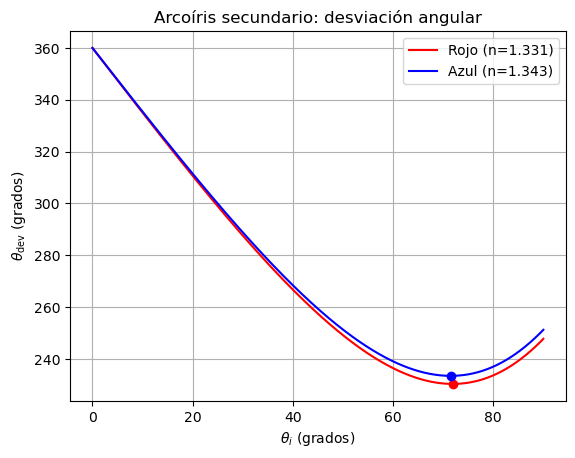

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def theta_dev(theta_i_deg, n, k):
    theta_i = np.deg2rad(theta_i_deg)
    s = np.sin(theta_i) / n
    s = np.clip(s, -1.0, 1.0)
    theta_r = np.arcsin(s)

    theta_dev_rad = np.deg2rad(180.0 * k) + 2*theta_i - 2*(k+1)*theta_r
    return np.rad2deg(theta_dev_rad)

# Parámetros
nR = 1.331
nB = 1.343
k = 2  # arcoíris secundario

theta_i_deg = np.linspace(0.0, 89.999, 200000)

dev_R = theta_dev(theta_i_deg, nR, k)
dev_B = theta_dev(theta_i_deg, nB, k)

# Mínimos
i_min_R = np.argmin(dev_R)
i_min_B = np.argmin(dev_B)

theta_i_min_R, dev_min_R = theta_i_deg[i_min_R], dev_R[i_min_R]
theta_i_min_B, dev_min_B = theta_i_deg[i_min_B], dev_B[i_min_B]

print("Secundario (k=2)")
print(f"Rojo:  theta_dev,min = {dev_min_R:.4f}°")
print(f"Azul:  theta_dev,min = {dev_min_B:.4f}°")
print(f"Ancho angular ≈ {abs(dev_min_B - dev_min_R):.4f}°")

# Gráfico
plt.figure()
plt.plot(theta_i_deg, dev_R, color='red', label=f"Rojo (n={nR})")
plt.plot(theta_i_deg, dev_B, color='blue', label=f"Azul (n={nB})")

plt.scatter(theta_i_min_R, dev_min_R, color='red')
plt.scatter(theta_i_min_B, dev_min_B, color='blue')

plt.xlabel(r"$\theta_i$ (grados)")
plt.ylabel(r"$\theta_{\mathrm{dev}}$ (grados)")
plt.title("Arcoíris secundario: desviación angular")
plt.legend()
plt.grid(True)
plt.show()


Secundario (k=2)
Rojo: theta_i* = 71.9073°, theta_dev,min = 230.3651°
Azul: theta_i* = 71.5215°, theta_dev,min = 233.4778°
Ancho angular ≈ 3.1126°


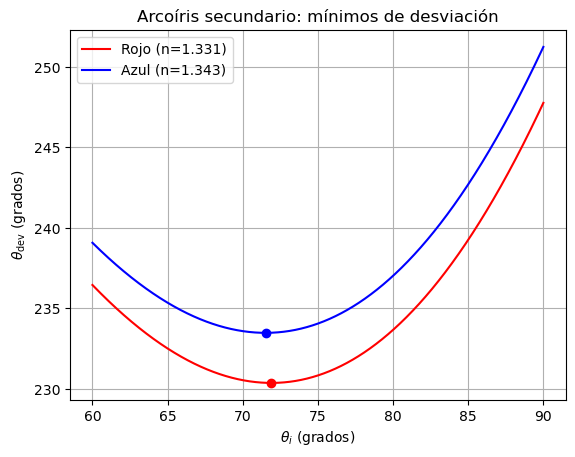

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def theta_dev(theta_i_deg, n, k):
    theta_i = np.deg2rad(theta_i_deg)
    s = np.sin(theta_i) / n
    s = np.clip(s, -1.0, 1.0)
    theta_r = np.arcsin(s)

    theta_dev_rad = np.deg2rad(180.0 * k) + 2*theta_i - 2*(k+1)*theta_r
    return np.rad2deg(theta_dev_rad)

# Parámetros
nR = 1.331
nB = 1.343
k = 2  # arcoíris secundario

# Dominio restringido
theta_i_deg = np.linspace(60.0, 89.999, 200000)

dev_R = theta_dev(theta_i_deg, nR, k)
dev_B = theta_dev(theta_i_deg, nB, k)

# Mínimos
i_min_R = np.argmin(dev_R)
i_min_B = np.argmin(dev_B)

theta_i_min_R, dev_min_R = theta_i_deg[i_min_R], dev_R[i_min_R]
theta_i_min_B, dev_min_B = theta_i_deg[i_min_B], dev_B[i_min_B]

print("Secundario (k=2)")
print(f"Rojo: theta_i* = {theta_i_min_R:.4f}°, theta_dev,min = {dev_min_R:.4f}°")
print(f"Azul: theta_i* = {theta_i_min_B:.4f}°, theta_dev,min = {dev_min_B:.4f}°")
print(f"Ancho angular ≈ {abs(dev_min_B - dev_min_R):.4f}°")

# Gráfico
plt.figure()
plt.plot(theta_i_deg, dev_R, color='red', label=f"Rojo (n={nR})")
plt.plot(theta_i_deg, dev_B, color='blue', label=f"Azul (n={nB})")

plt.scatter(theta_i_min_R, dev_min_R, color='red', zorder=3)
plt.scatter(theta_i_min_B, dev_min_B, color='blue', zorder=3)

plt.xlabel(r"$\theta_i$ (grados)")
plt.ylabel(r"$\theta_{\mathrm{dev}}$ (grados)")
plt.title("Arcoíris secundario: mínimos de desviación")
plt.legend()
plt.grid(True)
plt.show()


Secundario (k=2)
Rojo: theta_i* = 71.9073°, theta_dev,min = 230.3651°
Azul: theta_i* = 71.5215°, theta_dev,min = 233.4778°
Ancho angular ≈ 3.1126°


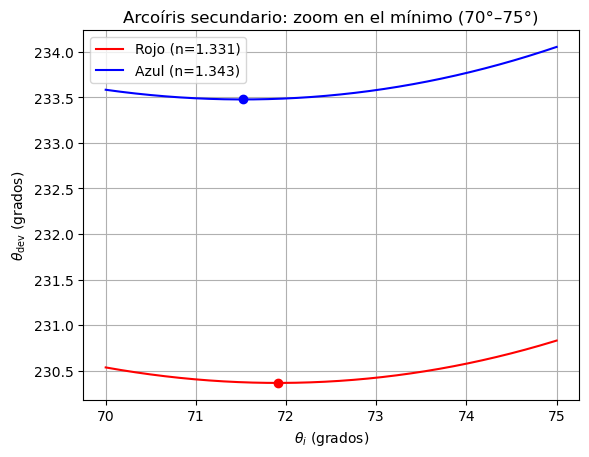

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def theta_dev(theta_i_deg, n, k):
    theta_i = np.deg2rad(theta_i_deg)
    s = np.sin(theta_i) / n
    s = np.clip(s, -1.0, 1.0)
    theta_r = np.arcsin(s)

    theta_dev_rad = np.deg2rad(180.0 * k) + 2*theta_i - 2*(k+1)*theta_r
    return np.rad2deg(theta_dev_rad)

# Parámetros
nR = 1.331
nB = 1.343
k = 2  # arcoíris secundario

# Dominio muy focalizado
theta_i_deg = np.linspace(70.0, 75.0, 200000)

dev_R = theta_dev(theta_i_deg, nR, k)
dev_B = theta_dev(theta_i_deg, nB, k)

# Mínimos
i_min_R = np.argmin(dev_R)
i_min_B = np.argmin(dev_B)

theta_i_min_R, dev_min_R = theta_i_deg[i_min_R], dev_R[i_min_R]
theta_i_min_B, dev_min_B = theta_i_deg[i_min_B], dev_B[i_min_B]

print("Secundario (k=2)")
print(f"Rojo: theta_i* = {theta_i_min_R:.4f}°, theta_dev,min = {dev_min_R:.4f}°")
print(f"Azul: theta_i* = {theta_i_min_B:.4f}°, theta_dev,min = {dev_min_B:.4f}°")
print(f"Ancho angular ≈ {abs(dev_min_B - dev_min_R):.4f}°")

# Gráfico
plt.figure()
plt.plot(theta_i_deg, dev_R, color='red', label=f"Rojo (n={nR})")
plt.plot(theta_i_deg, dev_B, color='blue', label=f"Azul (n={nB})")

plt.scatter(theta_i_min_R, dev_min_R, color='red', zorder=3)
plt.scatter(theta_i_min_B, dev_min_B, color='blue', zorder=3)

plt.xlabel(r"$\theta_i$ (grados)")
plt.ylabel(r"$\theta_{\mathrm{dev}}$ (grados)")
plt.title("Arcoíris secundario: zoom en el mínimo (70°–75°)")
plt.legend()
plt.grid(True)
plt.show()


---

c) ¿Qué sucede en comparación para un arcoíris terciario?

**Solución**

Se prodece igual, pero con $k=3$.

Terciario (k=3)
Rojo: theta_i* = 76.8914°, theta_dev,min = 317.5251°
Azul: theta_i* = 76.6166°, theta_dev,min = 321.8945°
Ancho angular ≈ 4.3694°


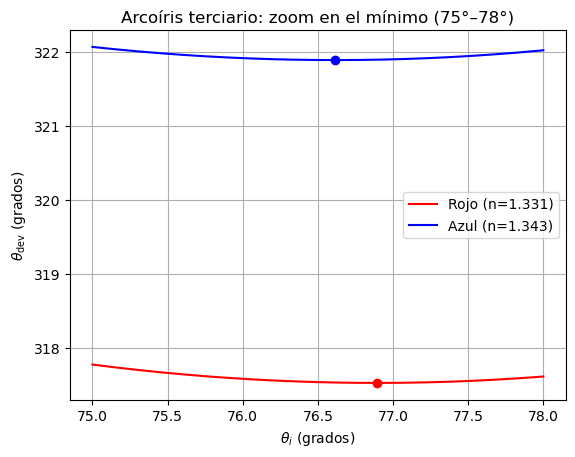

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def theta_dev(theta_i_deg, n, k):
    theta_i = np.deg2rad(theta_i_deg)
    s = np.sin(theta_i) / n
    s = np.clip(s, -1.0, 1.0)
    theta_r = np.arcsin(s)

    theta_dev_rad = np.deg2rad(180.0 * k) + 2*theta_i - 2*(k+1)*theta_r
    return np.rad2deg(theta_dev_rad)

# Parámetros
nR = 1.331
nB = 1.343
k = 3  # arcoíris secundario

# Dominio muy focalizado
theta_i_deg = np.linspace(75.0, 78.0, 200000)

dev_R = theta_dev(theta_i_deg, nR, k)
dev_B = theta_dev(theta_i_deg, nB, k)

# Mínimos
i_min_R = np.argmin(dev_R)
i_min_B = np.argmin(dev_B)

theta_i_min_R, dev_min_R = theta_i_deg[i_min_R], dev_R[i_min_R]
theta_i_min_B, dev_min_B = theta_i_deg[i_min_B], dev_B[i_min_B]

print("Terciario (k=3)")
print(f"Rojo: theta_i* = {theta_i_min_R:.4f}°, theta_dev,min = {dev_min_R:.4f}°")
print(f"Azul: theta_i* = {theta_i_min_B:.4f}°, theta_dev,min = {dev_min_B:.4f}°")
print(f"Ancho angular ≈ {abs(dev_min_B - dev_min_R):.4f}°")

# Gráfico
plt.figure()
plt.plot(theta_i_deg, dev_R, color='red', label=f"Rojo (n={nR})")
plt.plot(theta_i_deg, dev_B, color='blue', label=f"Azul (n={nB})")

plt.scatter(theta_i_min_R, dev_min_R, color='red', zorder=3)
plt.scatter(theta_i_min_B, dev_min_B, color='blue', zorder=3)

plt.xlabel(r"$\theta_i$ (grados)")
plt.ylabel(r"$\theta_{\mathrm{dev}}$ (grados)")
plt.title("Arcoíris terciario: zoom en el mínimo (75°–78°)")
plt.legend()
plt.grid(True)
plt.show()
